In [5]:
import numpy as np
import matplotlib.pyplot as plt

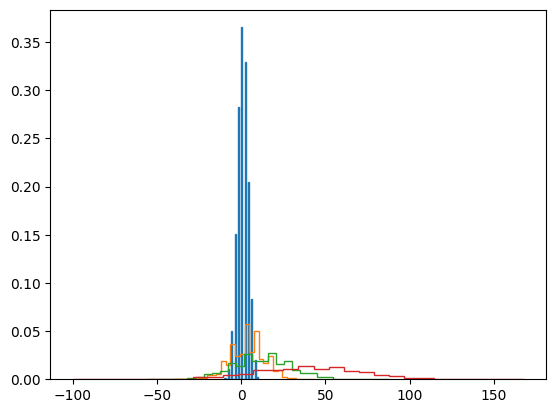

In [6]:
p = 0.52

ts = [10,100,300,1000]

for t in ts:
    xt = ((np.random.binomial(1,p,size=(100000,t))-0.5)*2).sum(axis=1)
    plt.hist(xt, bins=30, histtype='step', density=True)

In [7]:
isd1 = np.random.weibull(2, size=1000)
isd2 = np.random.weibull(2, size=1000)

print(isd1.mean(), isd2.mean())

d1 = isd1.cumsum()
d2 = isd2.cumsum()

dd = np.concatenate([d1,d2])
dd.sort()

def meanisd(arr):
    res = (arr[1:] - arr[:-1]).mean()
    print(res)
    return res

meanisd(dd[::2])






0.8795315284013893 0.8829820653892885
0.8817661599495693


0.8817661599495693

In [79]:
from numba import jit
from typing import List

# @jit(nopython=True)
def f(x: List[float] , lbd: float, epochs: int):
    for _ in range(epochs):
        x.append(lbd * x[-1] * (1-x[-1]))
    
    return x

epochs =1000

Xs = []
Ys = []


for lbd in np.linspace(2.5,4,2000):
    xt = f([0.5], lbd, epochs)

    X = [lbd] * 80
    Y = xt[-80:]

    Xs.append(X)
    Ys.append(Y)


In [71]:
# fig, ax = plt.subplots(1,1,figsize=(6,4), dpi=1000)

# for X, Y in zip(Xs, Ys):
#     ax.scatter(X, Y, s=2, c='black', alpha=0.5, linewidths=0, edgecolors='white', marker='.')